In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from statsbombpy import sb

matches = sb.matches(competition_id=37, season_id=281)
arsenal_matches = matches[
    (matches['home_team'] == 'Arsenal WFC') | (matches['away_team'] == 'Arsenal WFC')
]
arsenal_matches[['match_id', 'home_team', 'away_team', 'home_score', 'away_score', 'match_date']]

/Users/himankarsharma/.pyenv/versions/football-intelligence/lib/python3.12/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,home_team,away_team,home_score,away_score,match_date
17,3913185,Arsenal WFC,Brighton & Hove Albion WFC,5,0,2024-05-18
22,3913169,Arsenal WFC,Leicester City WFC,3,0,2024-04-21
30,3913160,Arsenal WFC,Bristol City WFC,5,0,2024-04-14
35,3913156,Aston Villa W,Arsenal WFC,1,3,2024-03-24
39,3913152,Chelsea FCW,Arsenal WFC,3,1,2024-03-15
40,3913130,West Ham United LFC,Arsenal WFC,2,1,2024-02-04
41,3913135,Arsenal WFC,Manchester United W,3,1,2024-02-17
44,3913125,Liverpool WFC,Arsenal WFC,0,2,2024-01-28
47,3913117,Arsenal WFC,Everton LFC,2,1,2024-01-20
49,3913113,Tottenham Hotspur Women,Arsenal WFC,1,0,2023-12-16


In [10]:
matches[matches['match_id'] == 3913083][['match_id', 'home_team', 'away_team', 'home_score', 'away_score', 'match_date', 'competition_stage']]

,match_id,home_team,away_team,home_score,away_score,match_date,competition_stage
125,3913083,Arsenal WFC,Manchester City WFC,2,1,2023-11-05,Regular Season


In [11]:
import sys

sys.path.append("..")
from pathlib import Path


In [12]:
from src.ingestion.loader import load_events

df = load_events(3913083)
df.dtypes


/Users/himankarsharma/.pyenv/versions/football-intelligence/lib/python3.12/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


event_id          str
match_id        int64
minute          int64
second          int64
period          int64
team              str
player            str
recipient         str
event_type        str
x             float64
y             float64
end_x         float64
end_y         float64
outcome           str
possession      int64
raw            object
dtype: object

In [26]:
from src.analytics.passing import calculate_progressive_passes

result = calculate_progressive_passes(df)
result.head(10)

,event_id,match_id,minute,second,period,team,player,recipient,event_type,x,y,end_x,end_y,outcome,possession,raw,progression
7,02d03d00-eec3-4412-b4e0-523b79a3cc62,3913083,0,3,1,Manchester City WFC,Alanna Stephanie Kennedy,Khadija Monifa Shaw,Pass,41.0,46.0,89.2,25.8,Incomplete,2,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",45.311742
10,4e7b9979-e576-459b-8852-9a85429c1e33,3913083,0,17,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,49.2,80.0,77.0,77.4,Incomplete,3,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",24.329019
11,f849554a-9eb4-4e13-97c3-204962bbde63,3913083,0,19,1,Manchester City WFC,Laia Aleixandri López,Khadija Monifa Shaw,Pass,43.1,3.3,74.2,0.1,Out,4,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",24.466078
12,7e6f63f3-bd17-48d4-93d0-1d743f8f2d36,3913083,0,34,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,56.0,80.0,77.4,76.3,Incomplete,5,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",19.503554
19,0f399782-9959-4b04-8904-9063a274eab3,3913083,1,1,1,Manchester City WFC,Laia Aleixandri López,Lauren Hemp,Pass,9.2,2.9,41.9,9.9,NaN,6,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",33.146685
30,b2490dd5-d358-4a29-b962-37f5b2df05f7,3913083,1,32,1,Manchester City WFC,Chloe Kelly,Khadija Monifa Shaw,Pass,100.0,68.7,103.0,26.5,NaN,6,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",13.272987
31,124b7591-301d-419e-ab5e-df6a4ca63788,3913083,2,2,1,Arsenal WFC,Manuela Zinsberger,Caitlin Jade Foord,Pass,7.0,36.1,49.1,14.8,NaN,7,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",37.822015
44,ebd6b738-2aa4-4890-93d3-c86b25c15673,3913083,3,16,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,62.6,68.8,77.8,60.0,Incomplete,8,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",17.520470
52,1c49b04d-6286-4ab8-b926-9af2f1ad9ab7,3913083,3,43,1,Manchester City WFC,Chloe Kelly,Khadija Monifa Shaw,Pass,77.4,60.5,102.9,53.8,NaN,9,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",25.302044
53,c3b4a830-875e-48bd-9106-5b5d4859cde6,3913083,3,49,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,10.7,37.2,52.6,40.4,NaN,9,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",41.934672


In [30]:
raw_df = sb.events(match_id=3913083)
raw_df[raw_df["type"] == "Carry"]

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
1989,NaN,NaN,NaN,NaN,NaN,NaN,"[43.1, 3.3]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:18.667,Carry,NaN
1990,NaN,NaN,NaN,NaN,NaN,NaN,"[56.8, 2.7]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:37.768,Carry,True
1991,NaN,NaN,NaN,NaN,NaN,NaN,"[49.7, 3.3]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:39.816,Carry,NaN
1992,NaN,NaN,NaN,NaN,NaN,NaN,"[41.3, 12.8]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:42.258,Carry,True
1993,NaN,NaN,NaN,NaN,NaN,NaN,"[26.9, 26.5]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:44.642,Carry,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2747,NaN,NaN,NaN,NaN,NaN,NaN,"[116.9, 75.1]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Arsenal WFC,968,01:02:22.343,Carry,True
2748,NaN,NaN,NaN,NaN,NaN,NaN,"[6.9, 15.1]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,01:02:27.697,Carry,NaN
2749,NaN,NaN,NaN,NaN,NaN,NaN,"[27.1, 47.5]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,01:02:29.678,Carry,NaN
2750,NaN,NaN,NaN,NaN,NaN,NaN,"[40.5, 66.4]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,01:02:45.302,Carry,NaN


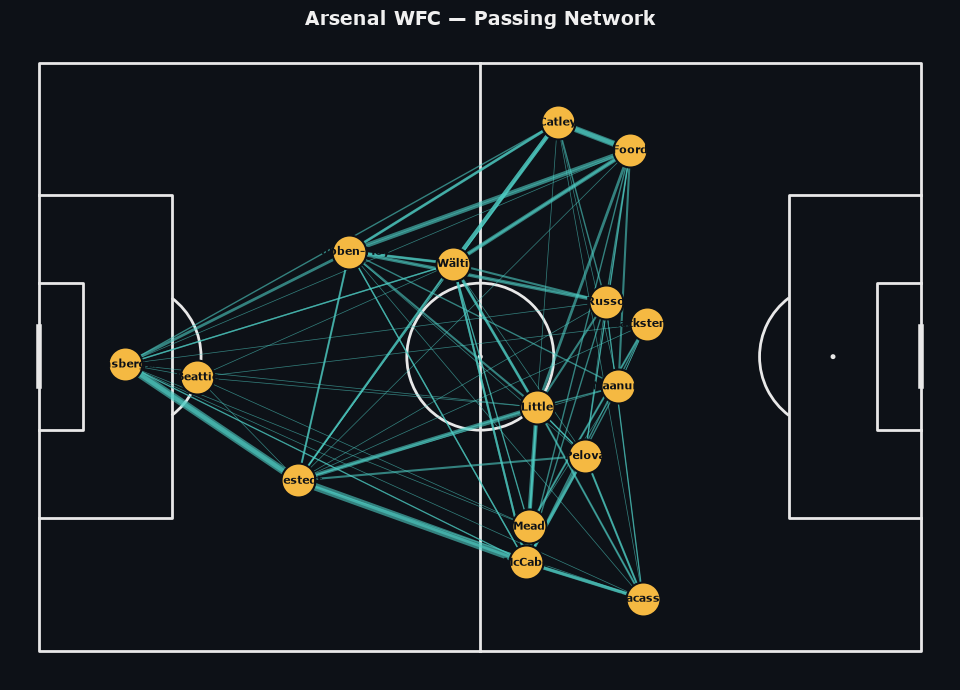

In [28]:
from src.ingestion.loader import load_events
from src.visualisation.pass_network import build_pass_network, plot_pass_network

events = load_events(3913083)
nodes, edges = build_pass_network(events, team="Arsenal WFC")
fig = plot_pass_network(nodes, edges, title="Arsenal WFC — Passing Network")
fig.savefig("arsenal_pass_network.png")

In [ ]:
from ingestion.loader import get_available_seasons
get_available_seasons(37)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
25,37,281,England,FA Women's Super League,female,False,False,2023/2024,2026-04-11T13:05:10.794831,NaN,NaN,2026-04-11T13:05:10.794831
26,37,90,England,FA Women's Super League,female,False,False,2020/2021,2026-04-12T16:33:48.145602,2021-06-13T16:17:31.694,NaN,2026-04-12T16:33:48.145602
27,37,42,England,FA Women's Super League,female,False,False,2019/2020,2026-04-12T16:07:56.102610,2021-06-13T16:17:31.694,NaN,2026-04-12T16:07:56.102610
28,37,4,England,FA Women's Super League,female,False,False,2018/2019,2026-03-28T18:13:53.368475,2021-06-13T16:17:31.694,NaN,2026-03-28T18:13:53.368475


findfont: Failed to find font weight medium, now using 400.


                  team  total_xg  actual_goals  shots
1  Manchester City WFC  1.774547             1     17
0          Arsenal WFC  0.738088             2     10


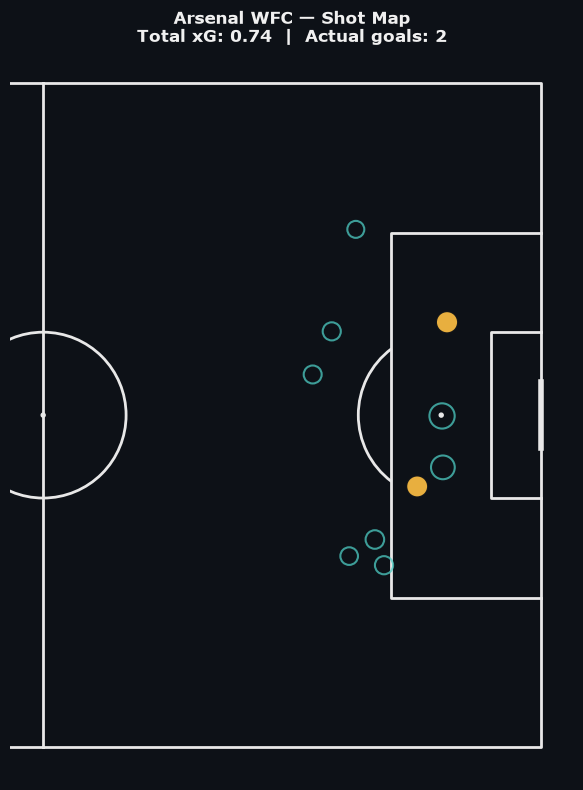

In [ ]:
from src.ingestion.loader import load_events_cached
from src.visualisation.shot_map import build_shot_map_data, plot_shot_map, team_xg_summary
import pandas as pd

events = load_events_cached(3913083)

arsenal_shots = build_shot_map_data(events, team="Arsenal WFC")
fig = plot_shot_map(arsenal_shots, team="Arsenal WFC", title="Arsenal WFC — Shot Map")
fig.savefig("arsenal_shot_map.png")

# combine both teams for the summary table
city_shots = build_shot_map_data(events, team="Manchester City WFC")
all_shots = pd.concat([arsenal_shots, city_shots])
print(team_xg_summary(all_shots))

In [ ]:
temp = build_shot_map_data(events, team="Arsenal WFC", model_path="../models/xg_model.pkl")
temp.columns


Index(['event_id', 'match_id', 'minute', 'second', 'period', 'team', 'player',
       'recipient', 'event_type', 'x', 'y', 'end_x', 'end_y', 'outcome',
       'possession', 'raw', 'distance', 'angle', 'is_goal', 'xg'],
      dtype='str')

In [21]:
from src.ingestion.loader import load_events_cached, get_all_match_ids
import pandas as pd
import joblib

COMPETITION_ID = 37
SEASON_IDS = [281, 90, 42, 4]  # your confirmed real season IDs

match_ids = get_all_match_ids(COMPETITION_ID, SEASON_IDS)

all_events = []
for i, match_id in enumerate(match_ids, start=1):
    try:
        events = load_events_cached(match_id)
        all_events.append(events)
    except Exception as e:
        print(f"skip {match_id}: {e}")
    if i % 50 == 0:
        print(f"loaded {i}/{len(match_ids)}")

all_events = pd.concat(all_events, ignore_index=True)
print(f"Total events: {len(all_events)}")

xg_model = joblib.load("../models/xg_model.pkl")  # or the corrected path

loaded 50/457
loaded 100/457
loaded 150/457
loaded 200/457
loaded 250/457
loaded 300/457
loaded 350/457
loaded 400/457
loaded 450/457
Total events: 1587305


In [22]:
from src.analytics.xt_model import build_move_and_shot_data

data = build_move_and_shot_data(all_events, xg_model)

In [23]:
from analytics.xt_model import compute_xt_grid
xt_grid = compute_xt_grid(data, 500, 1e-5)

ModuleNotFoundError: No module named 'analytics'

In [24]:
all_actions = all_events[all_events["event_type"].isin(["Pass", "Carry", "Shot"])].dropna(subset=["x","y"]).copy()
is_shot = all_actions["event_type"] == "Shot"
is_completed_move = (~is_shot) & (all_actions["outcome"].isna())
actions = all_actions[is_shot | is_completed_move].copy()
kept_fraction = len(actions) / len(all_actions)
print(f"Kept {kept_fraction:.1%} of raw actions after filtering to shots+completed moves")


Kept 86.5% of raw actions after filtering to shots+completed moves


  iteration 10 — max change: 0.006703
  iteration 20 — max change: 0.003360
  iteration 30 — max change: 0.002838
  iteration 40 — max change: 0.002152
  iteration 50 — max change: 0.001430
  iteration 60 — max change: 0.000899
  iteration 70 — max change: 0.000552
  iteration 80 — max change: 0.000336
  iteration 90 — max change: 0.000203
  iteration 100 — max change: 0.000122
  iteration 110 — max change: 0.000074
  iteration 120 — max change: 0.000044
  iteration 130 — max change: 0.000027
  iteration 140 — max change: 0.000016
  iteration 150 — max change: 0.000010
Converged after 150 iterations (tolerance=1e-05).
  iteration 10 — max change: 0.001045
  iteration 20 — max change: 0.000179
  iteration 30 — max change: 0.000037


findfont: Failed to find font weight medium, now using 400.


  iteration 38 — max change: 0.000009
Converged after 38 iterations (tolerance=1e-05).


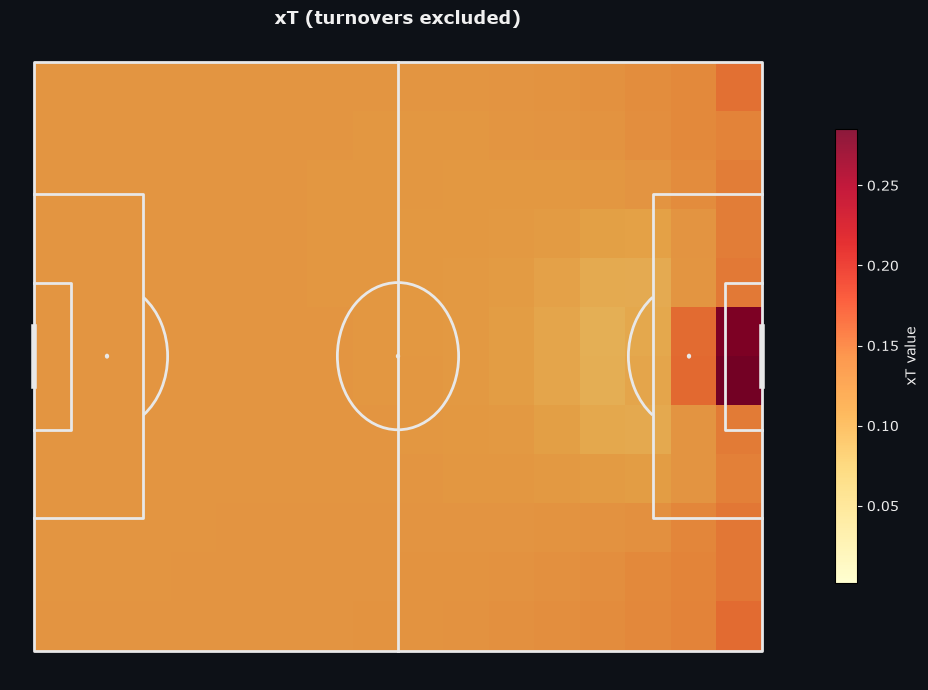

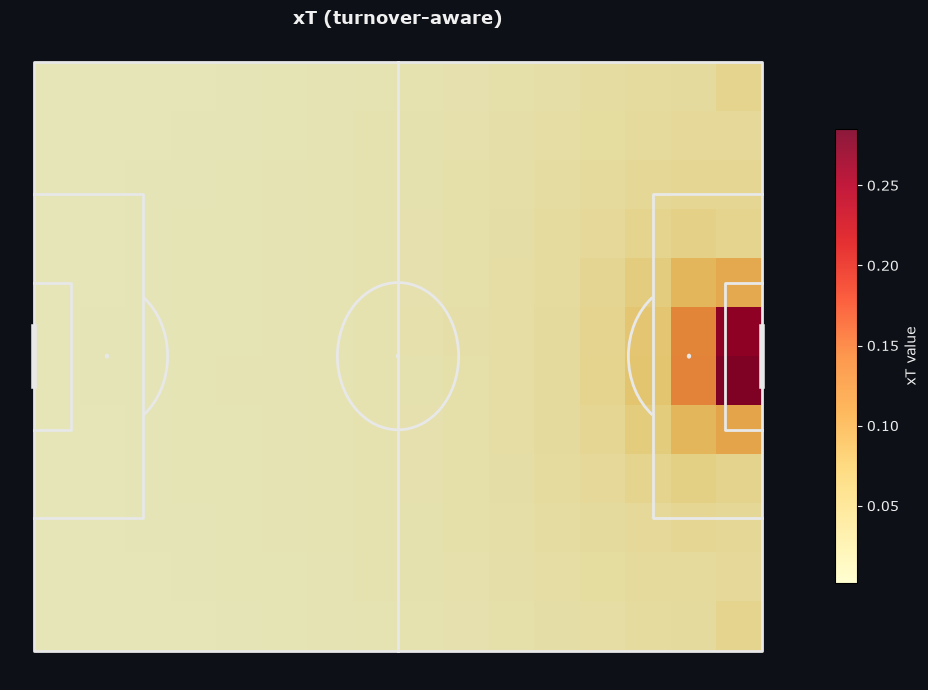

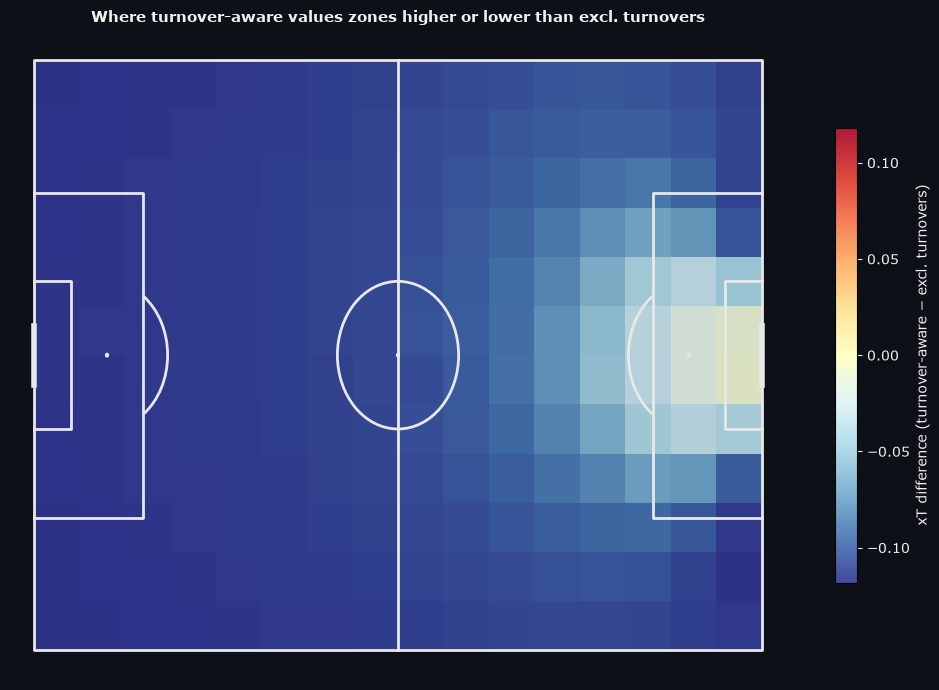

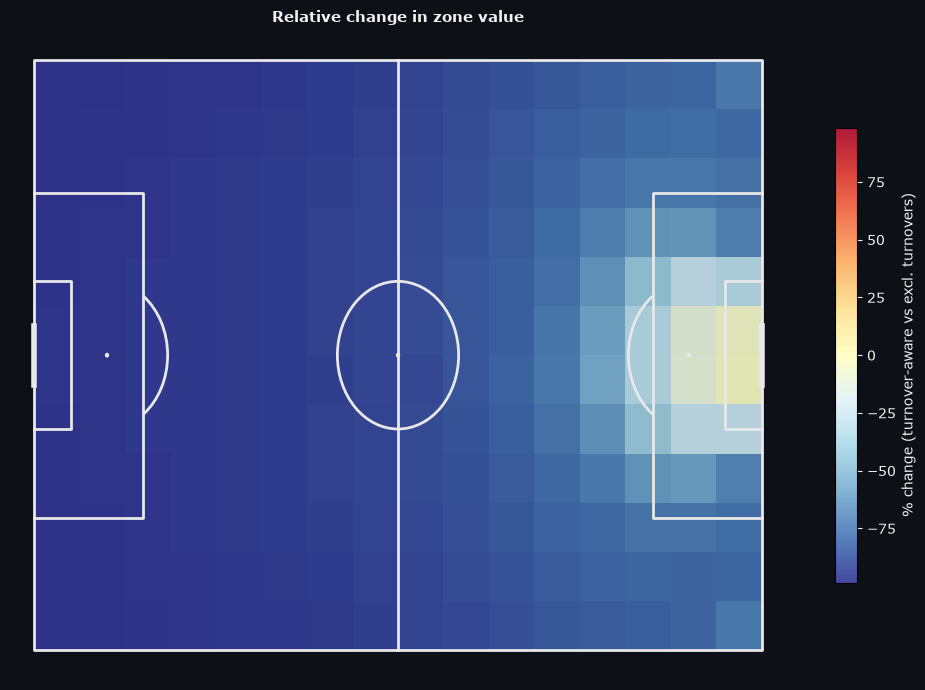

In [25]:
from src.analytics.xt_model import build_move_and_shot_data, compute_xt_grid
from src.visualisation.xt_heatmap import plot_xt_heatmap, plot_xt_diff, plot_xt_pct_change

data_no_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=False)
xt_no_turnover = compute_xt_grid(data_no_turnover)

data_with_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=True)
xt_with_turnover = compute_xt_grid(data_with_turnover)

shared_vmax = max(xt_no_turnover.max(), xt_with_turnover.max())
shared_vmin = min(xt_no_turnover.min(), xt_with_turnover.min())

fig1 = plot_xt_heatmap(xt_no_turnover, "xT (turnovers excluded)", vmin=shared_vmin, vmax=shared_vmax)
fig2 = plot_xt_heatmap(xt_with_turnover, "xT (turnover-aware)", vmin=shared_vmin, vmax=shared_vmax)
fig3 = plot_xt_diff(xt_no_turnover, xt_with_turnover, "excl. turnovers", "turnover-aware")
fig4 = plot_xt_pct_change(xt_no_turnover, xt_with_turnover, "excl. turnovers", "turnover-aware")

fig1.savefig("xt_no_turnover.png")
fig2.savefig("xt_with_turnover.png")
fig3.savefig("xt_diff.png")
fig4.savefig("xt_pct_change.png")

In [ ]:
import numpy as np

# restrict to the attacking-third, central-channel region (roughly zone 14 + box-edge area)
# columns 9-13 (near box), rows 3-8 (central channels)
region_cols = range(9, 14)
region_rows = range(3, 9)

region_values = xt_no_turnover[np.ix_(region_cols, region_rows)]
min_local = np.unravel_index(np.argmin(region_values), region_values.shape)

actual_col = list(region_cols)[min_local[0]]
actual_row = list(region_rows)[min_local[1]]

print(f"Darkest cell in this region: (col={actual_col}, row={actual_row}), value={xt_no_turnover[actual_col, actual_row]:.4f}")

Darkest cell in this region: (col=12, row=5), value=0.0928


In [ ]:
def inspect_zone(col, row, data):
    print(f"({col},{row}): "
          f"shot_prob={data['shot_prob'].get((col,row), 0):.4f}  "
          f"shot_value={data['shot_value'].get((col,row), 0):.4f}  "
          f"move_prob={data['move_prob'].get((col,row), 0):.4f}  "
          f"move_count={data['move_counts'].get((col,row), 0)}")

for dc in [-1, 0, 1]:
    for dr in [-1, 0, 1]:
        inspect_zone(actual_col + dc, actual_row + dr, data_no_turnover)

(11,4): shot_prob=0.0393  shot_value=0.0295  move_prob=0.9607  move_count=2346
(11,5): shot_prob=0.0631  shot_value=0.0312  move_prob=0.9369  move_count=2064
(11,6): shot_prob=0.0609  shot_value=0.0320  move_prob=0.9391  move_count=2266
(12,4): shot_prob=0.1339  shot_value=0.0460  move_prob=0.8661  move_count=2134
(12,5): shot_prob=0.1913  shot_value=0.0512  move_prob=0.8087  move_count=1492
(12,6): shot_prob=0.1987  shot_value=0.0512  move_prob=0.8013  move_count=1625
(13,4): shot_prob=0.2762  shot_value=0.0698  move_prob=0.7238  move_count=1271
(13,5): shot_prob=0.3610  shot_value=0.0874  move_prob=0.6390  move_count=1030
(13,6): shot_prob=0.3527  shot_value=0.0869  move_prob=0.6473  move_count=1105


In [ ]:
for zone in [(11,4), (11,5), (11,6)]:
    dests = data_no_turnover["transition_counts"].loc[zone] if zone in data_no_turnover["transition_counts"].index.droplevel([2,3]).unique() else None
    print(zone, "-> top destinations:")
    print(data_no_turnover["transition_counts"].loc[zone].sort_values(ascending=False).head(5))
    print()

(11, 4) -> top destinations:
end_col  end_row
11       4          631
12       4          164
11       5          141
         3          119
10       4           95
dtype: int64

(11, 5) -> top destinations:
end_col  end_row
11       5          558
         6          162
         4          107
12       5           97
         4           94
dtype: int64

(11, 6) -> top destinations:
end_col  end_row
11       6          614
12       6          171
11       5          130
         7          126
12       7           96
dtype: int64



In [ ]:
for zone in [(11,4), (11,5), (11,6)]:
    dests = data_no_turnover["transition_counts"].loc[zone]
    total = dests.sum()
    for (ec, er), count in dests.sort_values(ascending=False).head(5).items():
        print(f"{zone} -> ({ec},{er}): prob={count/total:.3f}, xT there={xt_no_turnover[ec,er]:.4f}")
    print()

(11, 4) -> (11,4): prob=0.269, xT there=0.1066
(11, 4) -> (12,4): prob=0.070, xT there=0.0983
(11, 4) -> (11,5): prob=0.060, xT there=0.1029
(11, 4) -> (11,3): prob=0.051, xT there=0.1124
(11, 4) -> (10,4): prob=0.040, xT there=0.1130

(11, 5) -> (11,5): prob=0.270, xT there=0.1029
(11, 5) -> (11,6): prob=0.078, xT there=0.1033
(11, 5) -> (11,4): prob=0.052, xT there=0.1066
(11, 5) -> (12,5): prob=0.047, xT there=0.0928
(11, 5) -> (12,4): prob=0.046, xT there=0.0983

(11, 6) -> (11,6): prob=0.271, xT there=0.1033
(11, 6) -> (12,6): prob=0.075, xT there=0.0938
(11, 6) -> (11,5): prob=0.057, xT there=0.1029
(11, 6) -> (11,7): prob=0.056, xT there=0.1093
(11, 6) -> (12,7): prob=0.042, xT there=0.1006



In [ ]:
from analytics.xt_model import _zone_index

actions = all_events[all_events["event_type"].isin(["Pass", "Carry", "Shot"])].dropna(subset=["x", "y"]).copy()
actions["col"], actions["row"] = _zone_index(actions["x"].to_numpy(), actions["y"].to_numpy())

zone_actions = actions[(actions["col"] == 12) & (actions["row"].isin([4, 5, 6]))]
zone_actions["event_type"].value_counts()

event_type
Carry    3037
Pass     2971
Shot     1086
Name: count, dtype: int64

In [ ]:
import numpy as np

zone_moves = zone_actions[zone_actions["event_type"].isin(["Pass", "Carry"])].dropna(subset=["end_x", "end_y"])
zone_moves["move_distance"] = np.sqrt(
    (zone_moves["end_x"] - zone_moves["x"])**2 + (zone_moves["end_y"] - zone_moves["y"])**2
)
zone_moves["move_distance"].describe()

count    6008.000000
mean        9.623577
std         8.509321
min         0.000000
25%         2.780288
50%         7.615773
75%        14.287232
max        59.481089
Name: move_distance, dtype: float64

In [31]:
sample_shot = events[events["event_type"] == "Shot"].iloc[0]["raw"]
[k for k in sample_shot.keys() if "shot" in k.lower() or "pressure" in k.lower() or "first_time" in k.lower()]

['pass_assisted_shot_id',
 'pass_shot_assist',
 'shot_aerial_won',
 'shot_body_part',
 'shot_deflected',
 'shot_end_location',
 'shot_first_time',
 'shot_freeze_frame',
 'shot_key_pass_id',
 'shot_one_on_one',
 'shot_open_goal',
 'shot_outcome',
 'shot_saved_to_post',
 'shot_statsbomb_xg',
 'shot_technique',
 'shot_type',
 'under_pressure']

In [32]:
sample_shots = events[events["event_type"] == "Shot"]["raw"]
print(sample_shots.apply(lambda r: r.get("shot_type")).value_counts())
print(sample_shots.apply(lambda r: r.get("shot_body_part")).value_counts())

raw
Open Play    26
Penalty       1
Name: count, dtype: int64
raw
Right Foot    16
Left Foot      9
Head           2
Name: count, dtype: int64


In [34]:
from scripts.train_xg_model import build_shot_dataset, COMPETITION_ID, SEASON_IDS

all_shots = build_shot_dataset(COMPETITION_ID, SEASON_IDS)
for col in ["is_header", "is_free_kick", "under_pressure", "first_time"]:
    print(col, all_shots[col].value_counts().to_dict())

  processed 50/457
  processed 100/457
  processed 150/457
  processed 200/457
  processed 250/457
  processed 300/457
  processed 350/457
  processed 400/457
  processed 450/457
is_header {0: 9892, 1: 1924}
is_free_kick {0: 11492, 1: 324}
under_pressure {0: 9017, 1: 2799}
first_time {0: 8328, 1: 3488}
